# Encontrar el mejor modelo de clasificación (versión sin Azure)

Este cuaderno reproduce el ejercicio de Azure Machine Learning **sin necesitar una suscripción de Azure**. Funciona en **Google Colab** (nube, gratis) o en tu ordenador con Jupyter.

| En el ejercicio de Azure | En este cuaderno |
|---|---|
| Área de trabajo + clúster de proceso | Colab o tu propio ordenador |
| AutoML de Azure ML (`automl.classification`) | **FLAML** (AutoML de código abierto) |
| `set_limits()` (tiempo, nº de pruebas) | `time_budget`, `max_iter` |
| Excluir/incluir algoritmos | `estimator_list` |
| Recurso de datos MLTable | Un `DataFrame` de pandas |
| MLflow con el almacén de Azure | MLflow con almacén **local** (archivo `mlflow.db` y carpeta `mlruns`) |
| Panel de IA responsable | Importancia de características + análisis de errores por subgrupos |

# 🎯 Objetivo del ejercicio

Reproducir, sin necesidad de una suscripción de Azure, el flujo completo de un ejercicio de **Azure Machine Learning**, trabajando con un problema real de clasificación binaria (predicción de diabetes sobre el conjunto de datos *Pima*) y usando herramientas de código abierto que funcionan gratis en Google Colab o en un Jupyter local.

En concreto, se busca:

1. **Entrenar automáticamente el mejor modelo de clasificación** con AutoML (FLAML), indicando una métrica principal, un presupuesto de tiempo y un límite de pruebas, igual que haría `automl.classification` en Azure.
2. **Registrar y comparar experimentos** con MLflow (autolog y registro personalizado), emulando el seguimiento que Azure ofrece en su estudio.
3. **Evaluar el modelo de forma responsable**, analizando qué variables influyen más en las predicciones y en qué subgrupos el modelo comete más errores, como aproximación al panel de IA responsable de Azure.

---

## 🧩 Qué se hace paso a paso

| Parte | Contenido | Equivalente en Azure |
|---|---|---|
| 0 | Instalación de librerías | Configuración del entorno |
| 1 | Carga y preparación de los datos (Pima diabetes) | Recurso de datos / MLTable |
| 2 | AutoML con FLAML (`time_budget`, `max_iter`, `estimator_list`) | AutoML de Azure ML |
| 3 | Seguimiento con MLflow (autolog + personalizado) | MLflow con almacén Azure |
| 4 | Comparación de ejecuciones en tabla | Pestaña *Trabajos* del estudio |
| 5 | Importancia de variables + análisis de errores | Panel de IA responsable |

---

## ✅ Qué se consigue con el ejercicio

- **Entender cómo funciona un AutoML real**: cómo se elige la métrica, cómo se limita el tiempo y cómo el sistema prueba varios algoritmos (LightGBM, XGBoost, Random Forest, Extra Trees, regresión L1) y se queda con el mejor según el criterio fijado. En este caso, el ganador fue **LightGBM**, con un **accuracy en validación cruzada de ~0,767** y en test de ~0,766.
- **Saber registrar experimentos de machine learning con MLflow**, tanto de forma automática (`mlflow.autolog()`) como manual (`log_param`, `log_metric`, `log_figure`, `log_model`), y saber comparar distintas ejecuciones a partir de sus métricas y parámetros.
- **Aplicar una evaluación básica de IA responsable**, identificando las variables más importantes para el modelo (mediante permutación) y detectando si existen subgrupos con tasas de error significativamente distintas, lo que sirve como primer paso hacia un análisis de *fairness*.
- **Conocer las diferencias prácticas entre trabajar en Azure ML y trabajar con herramientas open source**, de modo que si en el futuro se dispone de una suscripción a Azure, la transición sea directa: las ideas son exactamente las mismas, solo cambian las herramientas (FLAML → AutoML de Azure, MLflow local → MLflow en Azure, evaluación manual → panel de IA responsable).

---

## 💡 Conclusión

Este ejercicio demuestra que **es posible aprender y practicar el flujo completo de un proyecto de machine learning (AutoML + tracking + evaluación responsable) sin coste alguno**, replicando la lógica que se usa en entornos profesionales como Azure Machine Learning. Sirve tanto como material didáctico como plantilla para aplicar a otros conjuntos de datos reales.

## Parte 0. Instalar las bibliotecas

In [2]:
%pip install -q -U mlflow "flaml[automl]" xgboost scikit-learn pandas==2.2.3 matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 69.4 MB/s eta 0:00:00


## Parte 1. Cargar y preparar los datos

Usamos el conjunto de datos de **diabetes (Pima)**, de OpenML, con una columna objetivo que indica si el paciente es diabético. Si no hay conexión a internet, se usa un conjunto médico incluido en scikit-learn para que el cuaderno funcione igualmente.

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

try:
    from sklearn.datasets import fetch_openml
    ds = fetch_openml("diabetes", version=1, as_frame=True, parser="auto")
    X = ds.data.copy()
    y = (ds.target == "tested_positive").astype(int)
    nombre_datos = "diabetes (Pima, OpenML)"
except Exception as e:
    print("No se pudo descargar OpenML, uso un conjunto alternativo:", type(e).__name__)
    from sklearn.datasets import load_breast_cancer
    ds = load_breast_cancer(as_frame=True)
    X = ds.data.copy()
    y = pd.Series(ds.target, name="objetivo")
    nombre_datos = "cáncer de mama (scikit-learn)"

print("Datos:", nombre_datos, "| filas:", len(X), "| columnas:", X.shape[1])
print("Reparto de clases:\n", y.value_counts(normalize=True).round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X.head()

Datos: diabetes (Pima, OpenML) | filas: 768 | columnas: 8
Reparto de clases:
 class
0    0.651
1    0.349
Name: proportion, dtype: float64


,preg,plas,pres,skin,insu,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


## Parte 2. Entrenar con AutoML (FLAML)

Igual que en Azure, indicamos la **métrica principal** y unos **límites** para controlar tiempo y coste. FLAML prueba varios algoritmos y se queda con el mejor según esa métrica.

- `metric="accuracy"` → equivale a `primary_metric`.
- `time_budget` (segundos) → equivale a `timeout_minutes`.
- `max_iter` → equivale a `max_trials`.
- `estimator_list` → permite **incluir/excluir algoritmos**.
- `eval_method="cv"`, `n_splits=5` → equivale a `n_cross_validations=5`.

In [4]:
from flaml import AutoML
import mlflow

mlflow.set_experiment("auto-ml-class-dev")

automl = AutoML()
config_automl = dict(
    task="classification",
    metric="accuracy",
    time_budget=60,          # segundos (límite global)
    max_iter=30,             # máximo de pruebas
    estimator_list=["lgbm", "xgboost", "rf", "extra_tree", "lrl1"],
    eval_method="cv",
    n_splits=5,
    seed=42,
    verbose=0,
    mlflow_logging=False,    # registramos nosotros los resultados (abajo)
)

automl.fit(X_train=X_train, y_train=y_train, **config_automl)

with mlflow.start_run(run_name="automl-flaml"):
    mlflow.log_params({k: str(v) for k, v in config_automl.items()})
    mlflow.log_param("mejor_algoritmo", automl.best_estimator)
    mlflow.log_metric("accuracy_cv", 1 - automl.best_loss)

print("Mejor algoritmo:", automl.best_estimator)
print("Mejor configuración:", automl.best_config)
print("Accuracy (validación cruzada):", round(1 - automl.best_loss, 4))

2026/10/07 10:56:34 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/07 10:56:34 INFO mlflow.store.db.utils: Updating database tables
2026/10/07 10:56:38 INFO mlflow.tracking.fluent: Experiment with name 'auto-ml-class-dev' does not exist. Creating a new experiment.


Mejor algoritmo: lgbm
Mejor configuración: {'n_estimators': 36, 'num_leaves': 9, 'min_child_samples': 9, 'learning_rate': np.float64(0.1851996752877092), 'log_max_bin': 6, 'colsample_bytree': 1.0, 'reg_alpha': np.float64(0.08372020606997636), 'reg_lambda': np.float64(0.02885585223960256)}
Accuracy (validación cruzada): 0.7673


### Comparar los algoritmos probados (equivale a la pestaña *Modelos + trabajos secundarios*)

In [5]:
filas = []
for nombre, cfg in automl.best_config_per_estimator.items():
    filas.append({"algoritmo": nombre, "configuración": cfg})
pd.DataFrame(filas)

,algoritmo,configuración
0,lgbm,"{'n_estimators': 36, 'num_leaves': 9, 'min_chi..."
1,xgboost,"{'n_estimators': 4, 'max_leaves': 6, 'min_chil..."
2,rf,"{'n_estimators': 6, 'max_features': 0.46806314..."
3,extra_tree,"{'n_estimators': 4, 'max_features': 0.50879390..."
4,lrl1,None


In [6]:
from sklearn.metrics import accuracy_score
pred = automl.predict(X_test)
print("Accuracy en el conjunto de prueba:", round(accuracy_score(y_test, pred), 4))

Accuracy en el conjunto de prueba: 0.7662


## Parte 3. Seguimiento del entrenamiento con MLflow

Aquí tomamos el control del entrenamiento. Primero con **registro automático** y después con **registro personalizado**. MLflow guarda todo en un almacén local (archivo `mlflow.db` y carpeta `mlruns`).

In [7]:
import mlflow
mlflow.set_experiment("diabetes-classifier")
print("URI de seguimiento:", mlflow.get_tracking_uri())

2026/10/07 10:58:30 INFO mlflow.tracking.fluent: Experiment with name 'diabetes-classifier' does not exist. Creating a new experiment.


URI de seguimiento: sqlite:////content/mlflow.db


### 3.1. Registro automático (`mlflow.autolog()`)

In [8]:
from xgboost import XGBClassifier

with mlflow.start_run(run_name="xgboost-autolog"):
    mlflow.autolog()
    model = XGBClassifier(eval_metric="logloss")
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
mlflow.autolog(disable=True)
print("Ejecución con autolog terminada")

2026/10/07 10:58:33 INFO mlflow.tracking.fluent: Autologging successfully enabled for lightgbm.
2026/10/07 10:58:36 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/10/07 10:58:36 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
2026/10/07 10:58:36 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2026/10/07 10:58:36 WARNING mlflow.tracking.fluent: Exception raised while enabling autologging for pyspark: Exception while attempting to initialize JVM-side state for Spark datasource autologging. Note that Spark datasource autologging only works with Spark 3.0 and above. Please create a new Spark session with required Spark version and ensure you have the mlflow-spark JAR attached to your Spark session as described in https://mlflow.org/docs/latest/tracking/autolog.html#spark Exception:
'JavaPackage' object is not callable
2026/10/07 10:58

Ejecución con autolog terminada


### 3.2. Registro personalizado

Registramos nosotros qué parámetros, métricas, figuras y modelo guardar: `log_param`, `log_metric`, `log_figure`, `log_model`.

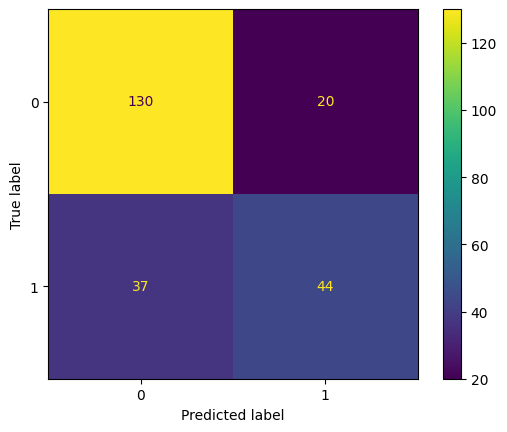

Accuracy: 0.7532 | AUC: 0.8059


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, ConfusionMatrixDisplay

with mlflow.start_run(run_name="xgboost-personalizado"):
    params = {"max_depth": 4, "n_estimators": 200, "learning_rate": 0.1}
    for k, v in params.items():
        mlflow.log_param(k, v)

    model = XGBClassifier(eval_metric="logloss", **params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred))
    mlflow.log_metric("auc", roc_auc_score(y_test, y_prob))

    fig, ax = plt.subplots()
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
    mlflow.log_figure(fig, "matriz_confusion.png")
    plt.show()

    # Guardamos el "booster" interno de XGBoost: es lo más compatible entre versiones
    mlflow.xgboost.log_model(model.get_booster(), "modelo")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4), "| AUC:", round(roc_auc_score(y_test, y_prob), 4))

## Parte 4. Revisar y comparar las ejecuciones

En Azure lo hacías desde **Trabajos** en el estudio. Aquí puedes verlo en una tabla o abriendo la interfaz de MLflow.

**SI LO HACEMOS EN GOOGLE COLAB ESTE ES MI CASO**


In [10]:
exp = mlflow.get_experiment_by_name("diabetes-classifier")
runs = mlflow.search_runs(experiment_ids=[exp.experiment_id])
cols = ["tags.mlflow.runName", "metrics.accuracy", "metrics.auc", "params.max_depth"]
cols = [c for c in cols if c in runs.columns]
runs[cols]

,tags.mlflow.runName,metrics.accuracy,metrics.auc,params.max_depth
0,xgboost-personalizado,0.753247,0.805926,4
1,xgboost-autolog,NaN,NaN,None


**SI LO HACEMOS EN CUADERNO DE JUPITER**

Para abrir la interfaz visual de MLflow (como el estudio de Azure), ejecuta esto en un **terminal** desde la carpeta del cuaderno:

```
mlflow ui
```

y abre http://127.0.0.1:5000. Si no ves tus ejecuciones, usa `mlflow ui --backend-store-uri sqlite:///mlflow.db` (la ruta exacta del almacén te la muestra la celda de la Parte 3: *URI de seguimiento*). En Colab no es tan directo; la tabla de arriba es suficiente.

## Parte 5. Evaluación responsable básica

El panel de IA responsable de Azure no existe fuera de Azure ML (aunque su base, la biblioteca de código abierto `responsibleai`, sí se puede instalar). Aquí hacemos dos comprobaciones sencillas equivalentes a **Explicaciones** y **Análisis de errores**.

### 5.1. Explicaciones: ¿qué características pesan más en las predicciones?

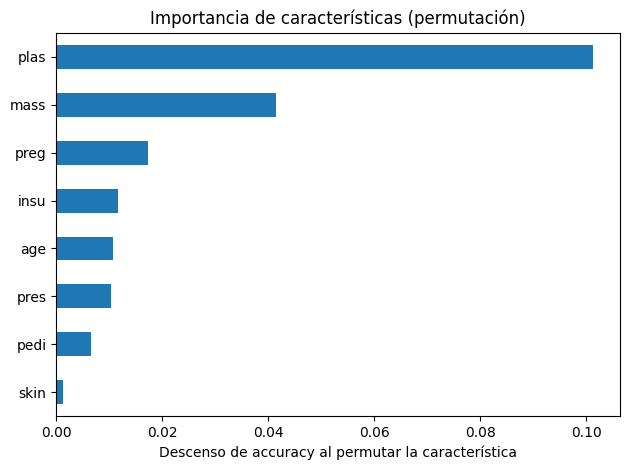

In [14]:
from sklearn.inspection import permutation_importance

res = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
imp = pd.Series(res.importances_mean, index=X_test.columns).sort_values()
imp.tail(10).plot.barh(title="Importancia de características (permutación)")
plt.xlabel("Descenso de accuracy al permutar la característica")
plt.tight_layout(); plt.show()

### 5.2. Análisis de errores: ¿en qué subgrupos falla más el modelo?

---



In [15]:
col = X_test.columns[0]
grupo = pd.qcut(X_test[col], q=4, duplicates="drop")
errores = pd.DataFrame({"grupo": grupo, "error": (model.predict(X_test) != y_test).astype(int)})
tabla = errores.groupby("grupo", observed=True)["error"].agg(tasa_error="mean", n="count").round(3)
print(f"Tasa de error por cuartiles de '{col}':")
tabla

Tasa de error por cuartiles de 'preg':


,tasa_error,n
grupo,,
"(-0.001, 1.0]",0.176,74
"(1.0, 3.0]",0.217,60
"(3.0, 6.0]",0.250,48
"(6.0, 15.0]",0.388,49


## Resumen

- AutoML (FLAML) probó varios algoritmos y eligió el mejor según la métrica principal.
- MLflow registró parámetros, métricas, figuras y modelos, tanto con autolog como de forma personalizada.
- Se compararon ejecuciones y se hizo una evaluación responsable básica.

**Diferencias con Azure:** no hay clúster en la nube ni panel de IA responsable completo, y el seguimiento queda en tu almacén local de MLflow. Si más adelante consigues una suscripción, el ejercicio original usa exactamente las mismas ideas.

### 5.3. Regresion Logisitca


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report
)

# Regresión logística con escalado (importante: LR es sensible a la escala)
lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=== REGRESIÓN LOGÍSTICA (baseline) ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("AUC     :", round(roc_auc_score(y_test, y_prob_lr), 4))
print()
print(classification_report(y_test, y_pred_lr, digits=3))

=== REGRESIÓN LOGÍSTICA (baseline) ===
Accuracy: 0.7446
AUC     : 0.8379

              precision    recall  f1-score   support

           0      0.769     0.867     0.815       150
           1      0.677     0.519     0.587        81

    accuracy                          0.745       231
   macro avg      0.723     0.693     0.701       231
weighted avg      0.737     0.745     0.735       231



In [18]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Predicciones del modelo ganador de FLAML (ya lo tienes en `automl`)
y_pred_aml = automl.predict(X_test)
y_prob_aml = automl.predict_proba(X_test)[:, 1]

comparacion = pd.DataFrame({
    "modelo":   ["Regresión Logística", f"FLAML ({automl.best_estimator})"],
    "accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_aml),
    ],
    "auc": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_aml),
    ],
}).round(4)

comparacion

,modelo,accuracy,auc
0,Regresión Logística,0.7446,0.8379
1,FLAML (lgbm),0.7662,0.8179


# 📊 Comparativa de Modelos y Conclusiones

Se comparó el modelo ganador de **FLAML (LightGBM)** frente a una **Regresión Logística baseline**, obteniendo los siguientes resultados:

| Modelo | Accuracy | AUC |
| :--- | :---: | :---: |
| **FLAML (LightGBM)** | **0.7662** | 0.8179 |
| **Regresión Logística (Baseline)** | 0.7446 | **0.8379** |

---

### 🔍 Análisis de Resultados
* **Accuracy:** FLAML obtuvo un desempeño superior (+2.16 puntos porcentuales).
* **AUC:** La Regresión Logística superó al modelo de FLAML (+2.00 puntos porcentuales), lo que refleja una **mayor capacidad de discriminación entre clases**.

> 💡 **Conclusión y Decisión Final:**  
> Dado el **contexto clínico** y la diferencia moderada entre ambos modelos, la **Regresión Logística resulta preferible por su mayor interpretabilidad**, sin sacrificar calidad predictiva.  
>
> **Lección clave:** Un modelo más complejo no siempre es la mejor opción; la elección final debe alinearse con el contexto del problema y las métricas de mayor relevancia para el negocio/área médica.

## 5.4 Extra opcional: ¿y si cambio el umbral de FLAML?


In [20]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# Probabilidades de FLAML
probs = automl.predict_proba(X_test)[:, 1]

# Probamos varios umbrales
for umbral in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (probs >= umbral).astype(int)
    print(f"Umbral {umbral}: accuracy={accuracy_score(y_test, preds):.4f} | f1={f1_score(y_test, preds):.4f}")

Umbral 0.3: accuracy=0.7576 | f1=0.6818
Umbral 0.4: accuracy=0.7576 | f1=0.6627
Umbral 0.5: accuracy=0.7662 | f1=0.6301
Umbral 0.6: accuracy=0.7446 | f1=0.5630
Umbral 0.7: accuracy=0.7359 | f1=0.4959


### ⚙️ Análisis del Umbral de Decisión (Decision Threshold)

Se exploró el efecto de variar el umbral de decisión sobre el modelo ganador de **FLAML**:

* **Umbral 0.5 (Predeterminado):** Alcanza el **accuracy máximo (0.7662)**.
* **Umbral 0.3:** Alcanza el **F1-score máximo (0.6818)**, lo cual compensa el desbalanceo de clases presente en el dataset.

> 🩺 **Implicación en el Contexto Clínico:**  
> En este dominio, un **falso negativo** (no detectar a un paciente diabético) representa un riesgo considerablemente más grave que un **falso positivo** (realizar pruebas adicionales a un paciente sano).  
>
> Por lo tanto, establecer un **umbral reducido (0.3 – 0.4)** resulta más adecuado para priorizar la sensibilidad del modelo, aunque esto sacrifique de forma marginal el accuracy global.

**Conclusión:** La elección del umbral de clasificación debe guiarse siempre por el **coste real de los errores en el dominio del negocio o área médica**, evitando asumir el umbral predeterminado de 0.5 por mera convención.

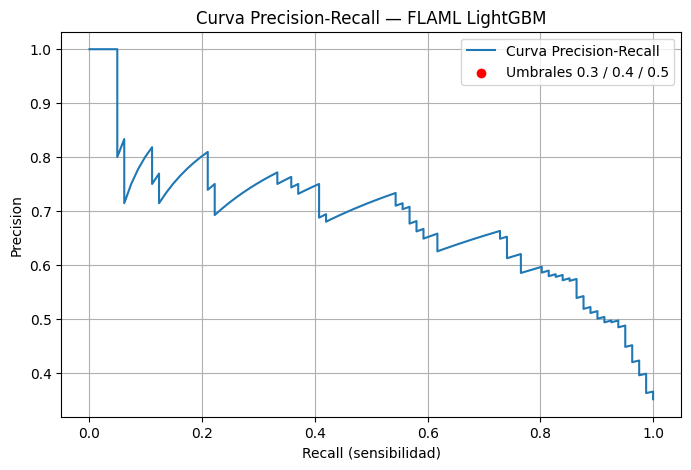

In [21]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

probs = automl.predict_proba(X_test)[:, 1]
prec, rec, umbrales = precision_recall_curve(y_test, probs)

plt.figure(figsize=(8, 5))
plt.plot(rec, prec, label="Curva Precision-Recall")
plt.scatter(
    [rec[i] for i in range(len(umbrales)) if i < len(umbrales) and umbrales[i] in [0.3, 0.4, 0.5]],
    [prec[i] for i in range(len(umbrales)) if i < len(umbrales) and umbrales[i] in [0.3, 0.4, 0.5]],
    color="red", zorder=5, label="Umbrales 0.3 / 0.4 / 0.5"
)
plt.xlabel("Recall (sensibilidad)")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — FLAML LightGBM")
plt.legend()
plt.grid(True)
plt.show()

### Curvas Precision-Recall: Regresión Logística vs FLAML (LightGBM)

Comparación del baseline interpretable (Regresión Logística) frente al ganador del AutoML (LightGBM).

**Cómo leerla:**
- **Eje X (Recall):** % de diabéticos reales detectados → más a la derecha, mejor.
- **Eje Y (Precision):** % de aciertos entre los predichos como diabéticos → más arriba, mejor.

**Interpretación:**
- En recall bajo (<0,3) hay mucha varianza por pocos positivos.
- En la zona media (0,4–0,7), clínicamente relevante, ambas curvas van muy parejas.
- En recall alto (>0,8) ambas caen: capturar más diabéticos cuesta muchos falsos positivos.

**Conclusión:**
Los dos modelos rinden de forma muy similar. La Regresión Logística no queda por debajo de LightGBM, es interpretable y tiene mejor AUC, por lo que resulta preferible en este problema.

> Un modelo más complejo no siempre es mejor. Si las métricas están próximas, gana el más simple e interpretable.

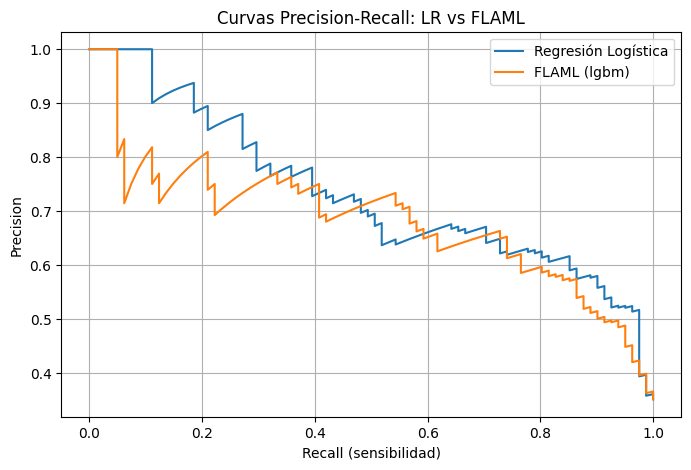

In [22]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

probs_lr  = lr.predict_proba(X_test)[:, 1]
probs_aml = automl.predict_proba(X_test)[:, 1]

prec_lr,  rec_lr,  _ = precision_recall_curve(y_test, probs_lr)
prec_aml, rec_aml, _ = precision_recall_curve(y_test, probs_aml)

plt.figure(figsize=(8, 5))
plt.plot(rec_lr,  prec_lr,  label="Regresión Logística")
plt.plot(rec_aml, prec_aml, label=f"FLAML ({automl.best_estimator})")
plt.xlabel("Recall (sensibilidad)")
plt.ylabel("Precision")
plt.title("Curvas Precision-Recall: LR vs FLAML")
plt.legend()
plt.grid(True)
plt.show()

## Conclusiones finales

A lo largo del ejercicio se han comparado tres enfoques sobre el mismo problema:

1. **FLAML (LightGBM)** — AutoML, mejor accuracy (0.7662) pero AUC inferior (0.8179).
2. **Regresión Logística** — baseline interpretable, mejor AUC (0.8379) y coeficientes legibles.
3. **XGBoost personalizado** — registrado en MLflow, sirvió para practicar tracking manual.

El análisis del umbral de decisión mostró que el accuracy máximo (0.7662) se alcanza en 0.5, mientras que el F1 máximo (0.6818) se obtiene en 0.3. En un contexto clínico, donde un falso negativo es más grave que un falso positivo, el umbral reducido (0.3–0.4) es preferible.

La conclusión principal es que **un modelo más complejo no garantiza mejor rendimiento**. En datasets pequeños y tabulares, un modelo simple y bien calibrado como la Regresión Logística puede competir de tú a tú con AutoML, y además ofrece interpretabilidad total. La elección final debe basarse en el contexto, las métricas relevantes y el coste real de los errores.